In [30]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Model parameters
# -----------------------------
v = np.array([4.0, 6.0, 7.0, 8.0])   # velocities (km/s)
u = 1.0 / v                     # slowness (s/km)
dz = np.array([3.0, 3.0, 3.0, 2.0])  # layer thickness (km)

# -----------------------------
# Function: Compute X(p), T(p)
# -----------------------------
def compute_X_T(u, dz, p):
    X = 0.0
    T = 0.0

    for i in range(len(u)):
        if u[i] > p:
            term = np.sqrt(u[i]**2 - p**2)
            X += 2 * dz[i] * p / term
            T += 2 * dz[i] * u[i]**2 / term

    return X, T


# -----------------------------
# Function: Ray Path
# -----------------------------
def ray_path(u, dz, p):
    x_points = [0]
    z_points = [0]

    x = 0
    z = 0

    # Down-going ray
    for i in range(len(u)):
        if u[i] > p:
            theta = np.arcsin(p / u[i])
            dx = dz[i] * np.tan(theta)

            x += dx
            z += dz[i]

            x_points.append(x)
            z_points.append(z)

    # Up-going ray
    for i in reversed(range(len(u))):
        if u[i] > p:
            theta = np.arcsin(p / u[i])
            dx = dz[i] * np.tan(theta)

            x += dx
            z -= dz[i]

            x_points.append(x)
            z_points.append(z)

    return np.array(x_points), np.array(z_points)






===== Single Ray Result =====
Offset X = 16.89 km
Travel Time T = 4.17 s


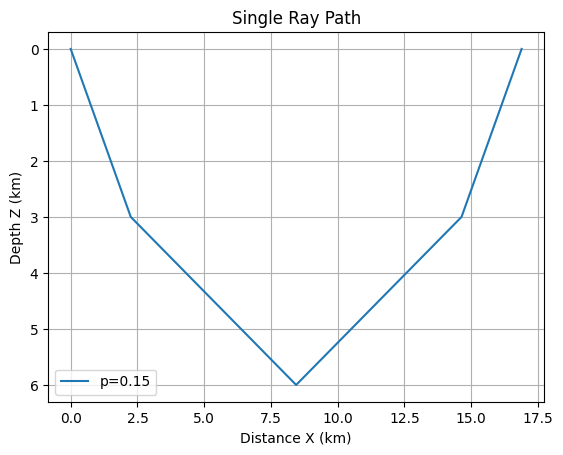

In [32]:
# -----------------------------
# Single Ray Example
# -----------------------------
p_single = 0.15
X, T = compute_X_T(u, dz, p_single)

print("===== Single Ray Result =====")
print(f"Offset X = {X:.2f} km")
print(f"Travel Time T = {T:.2f} s")

plt.figure()

x_ray, z_ray = ray_path(u, dz, p_single)
plt.plot(x_ray, z_ray, label=f"p={p_single:.2f}")

plt.gca().invert_yaxis()
plt.xlabel("Distance X (km)")
plt.ylabel("Depth Z (km)")
plt.title("Single Ray Path")
plt.grid()
plt.legend()
plt.show()

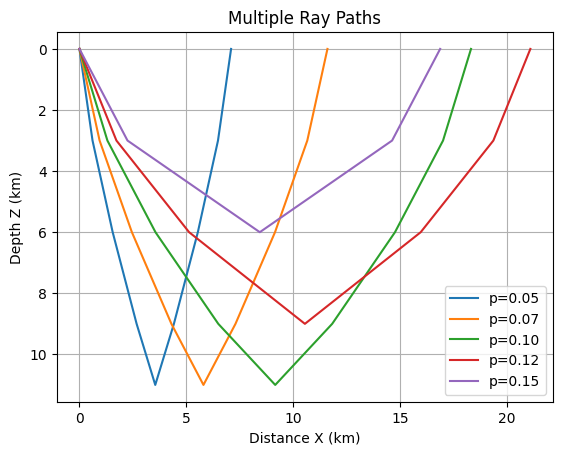

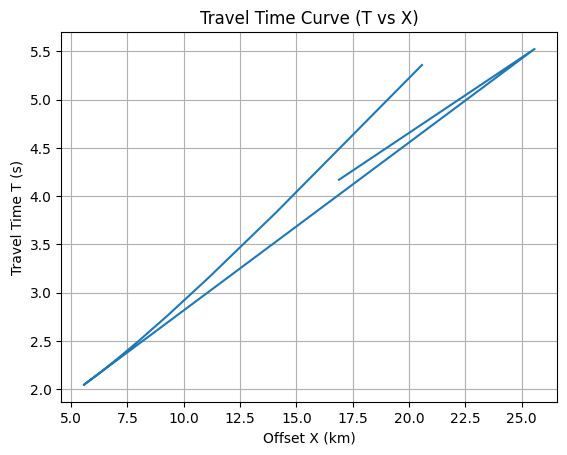

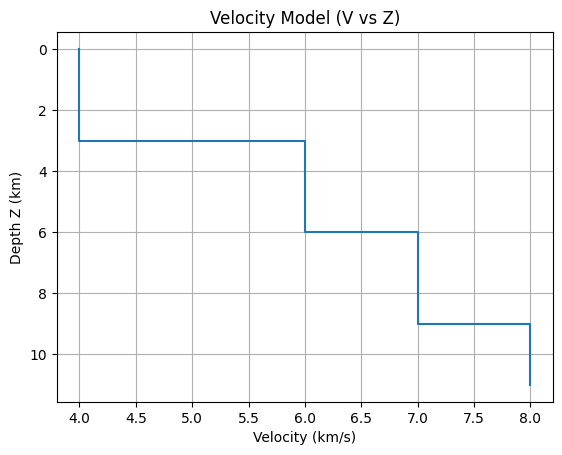

In [34]:

# -----------------------------
# Multiple Ray Paths
# -----------------------------
p_rays = np.linspace(0.05, 0.15, 5)

plt.figure()

for p_i in p_rays:
    x_ray, z_ray = ray_path(u, dz, p_i)
    plt.plot(x_ray, z_ray, label=f"p={p_i:.2f}")

plt.gca().invert_yaxis()
plt.xlabel("Distance X (km)")
plt.ylabel("Depth Z (km)")
plt.title("Multiple Ray Paths")
plt.grid()
plt.legend()
plt.show()


# -----------------------------
# Travel Time Curve T(X)
# -----------------------------
p_values = np.linspace(0.15, 0.24, 10)

X_vals = []
T_vals = []

for p_i in p_values:
    X_i, T_i = compute_X_T(u, dz, p_i)
    X_vals.append(X_i)
    T_vals.append(T_i)

X_vals = np.array(X_vals)
T_vals = np.array(T_vals)

plt.figure()
plt.plot(X_vals, T_vals)
plt.xlabel("Offset X (km)")
plt.ylabel("Travel Time T (s)")
plt.title("Travel Time Curve (T vs X)")
plt.grid()
plt.show()


# -----------------------------
# Velocity Model V(Z)
# -----------------------------
z_interfaces = np.concatenate(([0], np.cumsum(dz)))

z_plot = np.repeat(z_interfaces, 2)[1:-1]
v_plot = np.repeat(v, 2)

plt.figure()
plt.step(v_plot, z_plot, where='post')
plt.gca().invert_yaxis()
plt.xlabel("Velocity (km/s)")
plt.ylabel("Depth Z (km)")
plt.title("Velocity Model (V vs Z)")
plt.grid()
plt.show()